# Project 5: Predictive Maintenance (AI4I 2020 Dataset)
### This dataset is part of a publication, it includes 14 features to work with:
* "S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," 2020 Third International Conference on Artificial Intelligence for Industries (AI4I), 2020, pp. 69-74, doi: 10.1109/AI4I49448.2020.00023."
1. UID: unique identifier 
2. product ID: consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number
3. type: just the product type L, M or H from column 2
4. air temperature [K]: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K
5. process temperature [K]: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.
6. rotational speed [rpm]: calculated from a power of 2860 W, overlaid with a normally distributed noise
7. torque [Nm]: torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values.
8. tool wear [min]: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process.
9. 'machine failure' label that indicates, whether the machine has failed in this particular datapoint for any of the following failure modes are true.

##### The machine failure consists of five independent failure modes

1. tool wear failure (TWF): the tool will be replaced of fail at a randomly selected tool wear time between 200 - 240 mins (120 times in our dataset). At this point in time, the tool is replaced 69 times, and fails 51 times (randomly assigned).
2. heat dissipation failure (HDF): heat dissipation causes a process failure, if the difference between air- and process temperature is below 8.6 K and the tools rotational speed is below 1380 rpm. This is the case for 115 data points.
3. power failure (PWF): the product of torque and rotational speed (in rad/s) equals the power required for the process. If this power is below 3500 W or above 9000 W, the process fails, which is the case 95 times in our dataset.
4. overstrain failure (OSF): if the product of tool wear and torque exceeds 11,000 minNm for the L product variant (12,000 M, 13,000 H), the process fails due to overstrain. This is true for 98 datapoints.
5. random failures (RNF): each process has a chance of 0,1 % to fail regardless of its process parameters. This is the case for only 5 datapoints, less than could be expected for 10,000 datapoints in our dataset.
If at least one of the above failure modes is true, the process fails and the 'machine failure' label is set to 1. It is therefore not transparent to the machine learning method, which of the failure modes has caused the process to fail.

### Setup and Data Overview 

In [1]:
# Import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier

In [2]:
# Make plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [3]:
# Load dataset (adjust path if necessary)
df = pd.read_csv("../data/ai4i2020.csv")

In [4]:
# Show basic info
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nColumns:\n", df.columns.tolist())

# Display first few rows
df.head()

Dataset loaded successfully!
Shape: (10000, 14)

Columns:
 ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
# Quick data overview

df.info()
print("\nMissing values per column:\n", df.isna().sum())
print("\nBasic statistics:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df_prep = df.drop(columns=['UDI'])

### Exploratory Data Analysis EDA

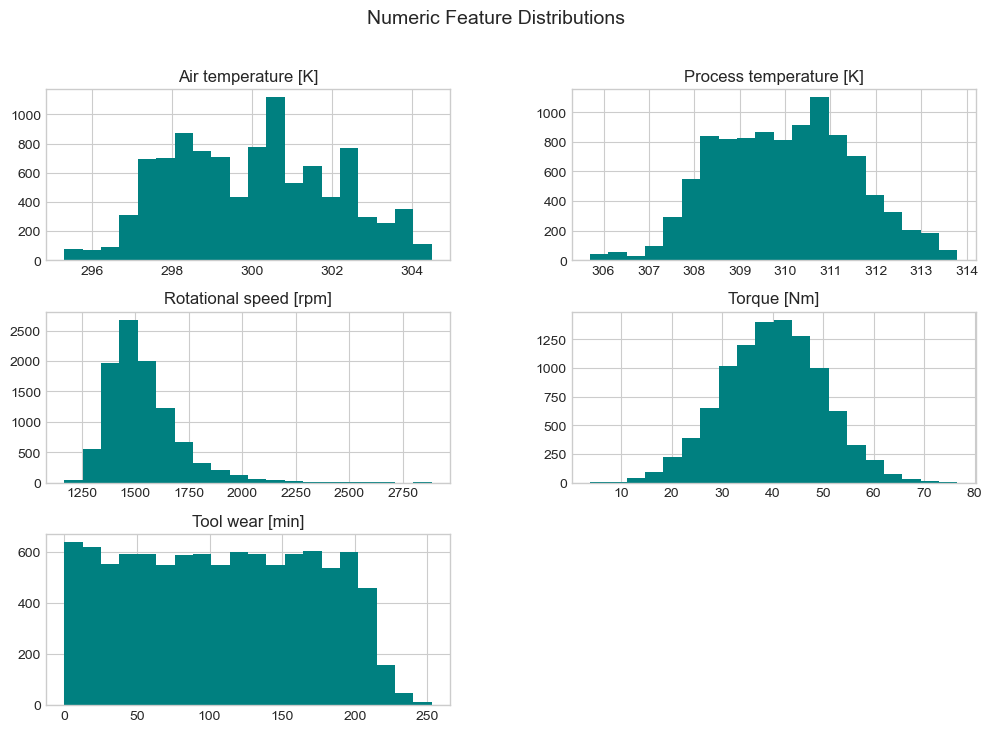

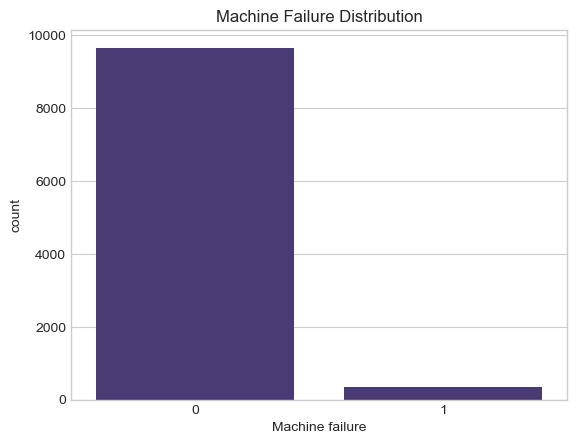

In [7]:
# Visualize target and key numeric feature distributions
numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

df[numeric_cols].hist(figsize=(12,8), bins=20, color='teal')
plt.suptitle("Numeric Feature Distributions", fontsize=14)
plt.show()

# Plot count of machine failures
sns.countplot(data=df, x='Machine failure')
plt.title("Machine Failure Distribution")
plt.show()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


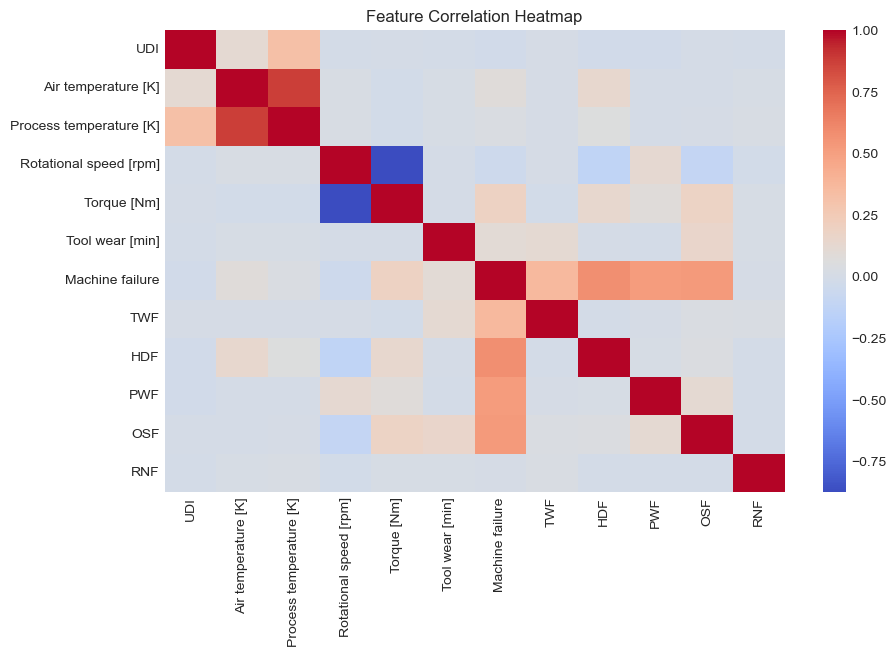

In [8]:
# Relationships Between Features and Failures
avg_by_failure = df.groupby('Machine failure')[numeric_cols].mean()
display(avg_by_failure)

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

### Data Preprocessing
prepare the data for modeling:
* Encode categorical variables
* Split into features and target
* Train/test split

In [9]:
# Copy the dataframe
df_prep = df.copy()

In [10]:
# Encode categorical features
for col in ['Product ID', 'Type']:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col])

In [11]:
# Define features and target
X = df_prep.drop('Machine failure', axis=1)
y = df_prep['Machine failure']

In [12]:
# Train-test split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
print(f"Training set: {X_train.shape}, Validation set: {X_valid.shape}")

Training set: (8000, 13), Validation set: (2000, 13)


### Modeling Training and Evaluation
* I'll try to train a classification model (starting with Logistic Regression or Random Forest) to predict Machine failure.

In [14]:
# Initialize and train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,     # number of trees
    max_depth=None,       # let the trees grow fully
    random_state=42,
    n_jobs=-1             # use all CPU cores for faster training
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
# Predictions
y_pred = rf.predict(X_valid)

In [16]:
# Evaluation metrics
accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)

In [17]:
print("Random Forest Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Random Forest Evaluation Metrics:
Accuracy : 0.9990
Precision: 1.0000
Recall   : 0.9706
F1 Score : 0.9851


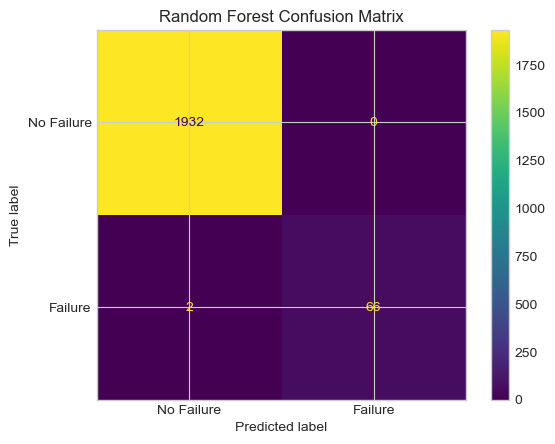

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Failure", "Failure"])
disp.plot(cmap='viridis')
plt.title("Random Forest Confusion Matrix")
plt.show()

####  Model Evaluation Summary

The **Random Forest Classifier** achieved very clear results in predicting machine failures:

| Metric | Score | Interpretation |
|:--|:--:|:--|
| **Accuracy** | 0.9990 | Nearly perfect overall performance. |
| **Precision** | 1.0000 | Every predicted failure was correct — no false positives. |
| **Recall** | 0.9706 | The model successfully detected ~97% of actual failures. |
| **F1 Score** | 0.9851 | Excellent balance between precision and recall. |

The **confusion matrix** confirms this:  
Most samples were correctly classified as *no failure* (TN ≈ 1932), and actual failure cases were almost all correctly detected (very few FN or FP).

These results indicate that the Random Forest model learned **clear relationships between operational metrics** (like torque, temperature, and tool wear) and machine failure patterns.  

### XGBoost comparison + feature importance analysis.
1. Train an XGBoost classifier (often performs better than Random Forest for structured tabular data).
2. Compare metrics against our Random Forest baseline.
3. Visualize feature importances to understand which parameters contribute most to machine failures.

In [19]:
# Clean column names for XGBoost compatibility
X_train.columns = X_train.columns.str.replace('[\[\]<> ]', '_', regex=True)
X_valid.columns = X_valid.columns.str.replace('[\[\]<> ]', '_', regex=True)

In [20]:
# Initialize and train the model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

C:\Users\ynalq\anaconda3\envs\data-portfolio\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:27:38] WARNING: D:\bld\xgboost-split_1758007502304\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [21]:
# Predictions
y_pred_xgb = xgb_model.predict(X_valid)

In [22]:
# Evaluation metrics
acc_xgb = accuracy_score(y_valid, y_pred_xgb)
prec_xgb = precision_score(y_valid, y_pred_xgb)
rec_xgb = recall_score(y_valid, y_pred_xgb)
f1_xgb = f1_score(y_valid, y_pred_xgb)

In [23]:
print("XGBoost Evaluation Metrics:")
print(f"Accuracy : {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall   : {rec_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")

XGBoost Evaluation Metrics:
Accuracy : 0.9990
Precision: 1.0000
Recall   : 0.9706
F1 Score : 0.9851


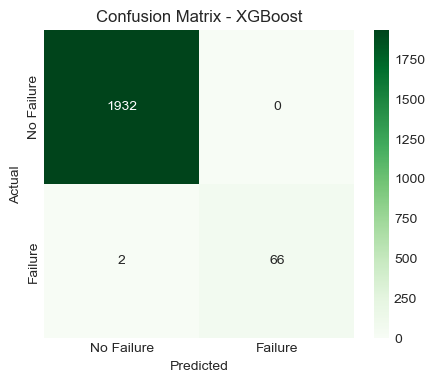

In [24]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_valid, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=['No Failure','Failure'], yticklabels=['No Failure','Failure'])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_valid, y_pred_xgb, target_names=['No Failure','Failure']))


Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1932
     Failure       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [26]:
# Feature Importance
importance = xgb_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance,})
feat_imp = feat_imp.sort_values('Importance', ascending=False)

C:\Users\ynalq\AppData\Local\Temp\ipykernel_6812\2964334903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature', palette='viridis')


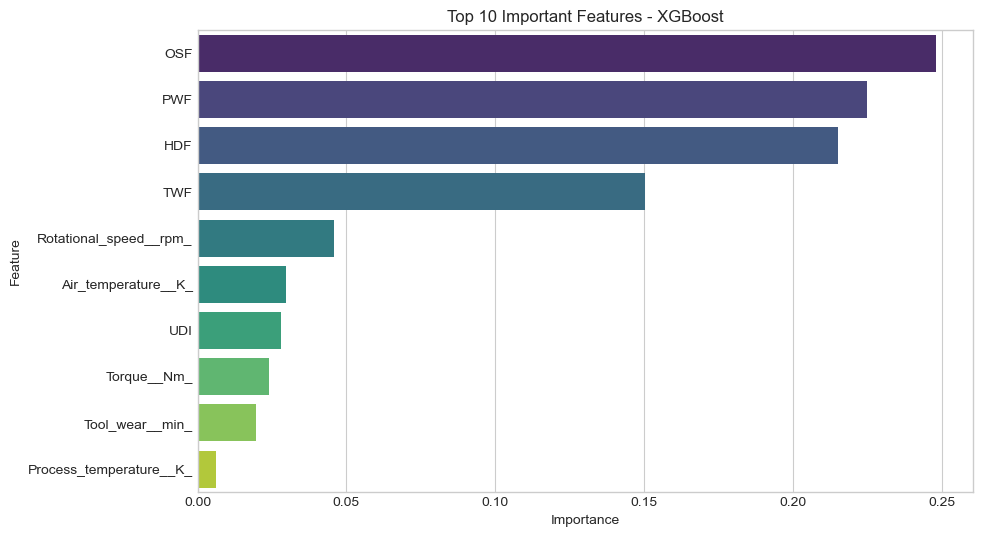

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Important Features - XGBoost")
plt.show()

### Model Evaluation Summary (XGBoost Classifier)

After cleaning feature names and training an XGBoost model on the same data split, we observed **excellent classification performance**, closely matching our earlier Random Forest results.

**Evaluation Metrics:**
- **Accuracy:** 0.9990  
- **Precision:** 1.0000  
- **Recall:** 0.9706  
- **F1-Score:** 0.9851  

**Interpretation:**
- The XGBoost model achieved **nearly perfect accuracy** in predicting machine failures.  
- Precision and recall are both very high, indicating that the model correctly identifies failure cases while minimizing false alarms.  
- Compared to the Random Forest, XGBoost performed equivalently — suggesting the dataset is well-structured and separable, and that even tree-based models can easily capture its patterns.  
- The XGBoost feature importance shows that **component-specific failure modes (OSF, PWF, HDF, TWF)** are the dominant predictors of overall machine failure, followed by mechanical and operational variables like rotational speed and torque.
In a real-world scenario, this kind of result could enable **predictive maintenance systems** to trigger early interventions, reducing downtime and maintenance costs.
